# Лабораторная работа. XAI и Интерпретируемые модели: Wine Quality (мультиклассовая классификация)

**Автор:** : Жунёв Андрей РИМ-150950

**Цель:** Продемонстрировать полный пайплайн мультиклассовой классификации качества красного вина: от EDA и обучения моделей до глобальной и локальной интерпретации.

**Набор данных:** [Wine Quality (Red Wine Dataset)](https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv)  
**Источник:** UCI Machine Learning Repository  
**Размер:** 1599 образцов × 12 признаков  
**Целевая переменная:** `quality` (оценка 3–8 баллов, 6 классов)

**Модели:** `RandomForestClassifier` (бэггинг над деревьями) и `CatBoostClassifier` (градиентный бустинг).


## Оглавление

1. [I. Загрузка и подготовка данных (EDA)](#I.-Загрузка-и-подготовка-данных-(EDA))
2. [II. Предварительная обработка данных](#II.-Предварительная-обработка-данных)
3. [III. Обучение базовых моделей](#III.-Обучение-базовых-моделей)
   - [1. Метрики для сравнения моделей](#1.-Метрики-для-сравнения-моделей)
   - [2. Выбор моделей](#2.-Выбор-моделей)
   - [3. Обучение Random Forest (базовая модель)](#3.-Обучение-Random-Forest-(базовая-модель))
   - [4. Обучение CatBoost (базовая модель)](#4.-Обучение-CatBoost-(базовая-модель))
   - [5. Сравнение базовых моделей](#5.-Сравнение-базовых-моделей)
4. [IV. Оптимизация выбранных моделей](#IV.-Оптимизация-выбранных-моделей)
   - [1. Оптимизация Random Forest (Optuna)](#1.-Оптимизация-Random-Forest-(Optuna))
   - [2. Оптимизация CatBoost (Optuna)](#2.-Оптимизация-CatBoost-(Optuna))
5. [V. Итоговое сравнение и анализ ошибок](#V.-Итоговое-сравнение-и-анализ-ошибок)
   - [1. Сводная таблица результатов](#1.-Сводная-таблица-результатов)
   - [2. Матрица ошибок (Confusion Matrix)](#2.-Матрица-ошибок-(Confusion-Matrix))
   - [3. ROC-кривые по классам](#3.-ROC-кривые-по-классам)
   - [4. Анализ пересечения ошибок](#4.-Анализ-пересечения-ошибок)
6. [VI. Интерпретируемость (XAI)](#VI.-Интерпретируемость-(XAI))
   - [1. Глобальная интерпретация](#1.-Глобальная-интерпретация)
   - [2. Локальная интерпретация](#2.-Локальная-интерпретация)
7. [VII. Выводы](#VII.-Выводы)


## Импорты

> Запустите эту ячейку один раз перед началом работы. Здесь же определены все вспомогательные функции, которые используются во всех разделах.


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from catboost import CatBoostClassifier, Pool

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

px.defaults.template = 'plotly_white'

print('✅ Все библиотеки успешно импортированы')


✅ Все библиотеки успешно импортированы


In [2]:
# ============================================================================
# ГЛОБАЛЬНЫЙ СПИСОК ДЛЯ ХРАНЕНИЯ РЕЗУЛЬТАТОВ ВСЕХ МОДЕЛЕЙ
# ============================================================================
MODEL_RESULTS = []


def calculate_multiclass_metrics(y_true, y_pred, y_proba):
    '''Вычисляет четыре ключевые метрики для мультиклассовой классификации.

    Параметры
    ----------
    y_true  : array-like, истинные метки (закодированные 0..K-1)
    y_pred  : array-like, предсказанные метки
    y_proba : array-like, матрица вероятностей (n_samples, n_classes)

    Возвращает
    ----------
    dict с ключами: Balanced Accuracy, F1 Macro, F1 Weighted, ROC AUC (OvR)
    '''
    return {
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'F1 Macro':          f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'F1 Weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'ROC AUC (OvR)':     roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro'),
    }


def add_result(model_name, features_desc, model, X_train, y_train, X_test, y_test):
    '''Обучает предсказания и сохраняет метрики в глобальный MODEL_RESULTS.

    Параметры
    ----------
    model_name    : str   — название модели
    features_desc : str   — описание набора признаков
    model         : fitted estimator
    X_train, y_train, X_test, y_test : данные
    '''
    y_train_pred  = np.array(model.predict(X_train)).flatten()
    y_test_pred   = np.array(model.predict(X_test)).flatten()
    y_train_proba = model.predict_proba(X_train)
    y_test_proba  = model.predict_proba(X_test)

    m_train = calculate_multiclass_metrics(y_train, y_train_pred, y_train_proba)
    m_test  = calculate_multiclass_metrics(y_test,  y_test_pred,  y_test_proba)

    gap = m_train['Balanced Accuracy'] - m_test['Balanced Accuracy']

    MODEL_RESULTS.append({
        'Model':              model_name,
        'Features':           features_desc,
        'Bal.Acc Train':      round(m_train['Balanced Accuracy'], 4),
        'Bal.Acc Test':       round(m_test['Balanced Accuracy'],  4),
        'Gap (Bal.Acc)':      round(gap, 4),
        'F1 Macro Train':     round(m_train['F1 Macro'], 4),
        'F1 Macro Test':      round(m_test['F1 Macro'],  4),
        'F1 Weighted Test':   round(m_test['F1 Weighted'], 4),
        'ROC AUC Test':       round(m_test['ROC AUC (OvR)'], 4),
    })

    if gap > 0.1:
        print(f'⚠️  {model_name}: возможное переобучение (Gap Bal.Acc = {gap:.4f})')
    else:
        print(f'✅ {model_name}: переобучение незначительное (Gap = {gap:.4f})')


print('✅ Функции calculate_multiclass_metrics() и add_result() созданы')


✅ Функции calculate_multiclass_metrics() и add_result() созданы


In [3]:
def plot_model_report_separate(
    metrics_dict,
    feature_importance,
    model_name,
    width_metrics=850,
    height_metrics=450,
    width_fi=800,
    height_fi=550,
):
    '''Строит два отдельных Plotly-графика: метрики Train vs Test и важность признаков.

    Параметры
    ----------
    metrics_dict : dict с ключами 'train' и 'test', каждый — dict метрик
    feature_importance : pd.DataFrame с колонками ['feature', 'importance'] или None
    model_name   : str
    '''
    metric_names = ['Balanced Accuracy', 'F1 Macro', 'F1 Weighted', 'ROC AUC (OvR)']
    train_vals   = [metrics_dict['train'].get(m, 0) for m in metric_names]
    test_vals    = [metrics_dict['test'].get(m, 0)  for m in metric_names]

    fig_m = go.Figure()
    fig_m.add_trace(go.Bar(
        name='Train', x=metric_names, y=train_vals,
        marker_color='steelblue',
        text=[f'{v:.4f}' for v in train_vals], textposition='auto',
    ))
    fig_m.add_trace(go.Bar(
        name='Test', x=metric_names, y=test_vals,
        marker_color='crimson',
        text=[f'{v:.4f}' for v in test_vals], textposition='auto',
    ))
    fig_m.update_layout(
        title={'text': f'Метрики качества: {model_name}', 'x': 0.5, 'xanchor': 'center'},
        xaxis_title='Метрика', yaxis_title='Значение',
        barmode='group', template='plotly_white',
        width=width_metrics, height=height_metrics,
        legend_title_text='Split',
        yaxis=dict(range=[0, 1.05]),
    )
    fig_m.show()

    if feature_importance is not None and len(feature_importance) > 0:
        fi = feature_importance.copy().sort_values('importance', ascending=True)
        fig_fi = go.Figure()
        fig_fi.add_trace(go.Bar(
            x=fi['importance'], y=fi['feature'],
            orientation='h', marker_color='coral',
        ))
        fig_fi.update_layout(
            title={'text': f'Важность признаков: {model_name}', 'x': 0.5, 'xanchor': 'center'},
            xaxis_title='Важность', yaxis_title='Признак',
            template='plotly_white', width=width_fi, height=height_fi, showlegend=False,
        )
        fig_fi.show()


print('✅ Функция plot_model_report_separate() создана')


✅ Функция plot_model_report_separate() создана


In [4]:
def add_wine_features(df):
    '''Добавляет 5 синтетических химических признаков к данным вина.

    Новые признаки:
    - total_acidity     : сумма всех кислот (fixed + volatile + citric)
    - vol_fixed_ratio   : отношение летучей к постоянной кислотности
    - free_so2_ratio    : доля свободного SO2 от общего
    - alc_density_prod  : произведение алкоголя и плотности (тело вина)
    - sugar_alc_ratio   : отношение остаточного сахара к алкоголю
    '''
    data = df.copy()
    data['total_acidity']    = data['fixed acidity'] + data['volatile acidity'] + data['citric acid']
    data['vol_fixed_ratio']  = data['volatile acidity'] / (data['fixed acidity'] + 1e-5)
    data['free_so2_ratio']   = data['free sulfur dioxide'] / (data['total sulfur dioxide'] + 1e-5)
    data['alc_density_prod'] = data['alcohol'] * data['density']
    data['sugar_alc_ratio']  = data['residual sugar'] / (data['alcohol'] + 1e-5)
    return data


NEW_FEATURE_NAMES = [
    'total_acidity', 'vol_fixed_ratio', 'free_so2_ratio',
    'alc_density_prod', 'sugar_alc_ratio',
]

print('✅ Функция add_wine_features() создана')
print(f'✅ Новые признаки: {NEW_FEATURE_NAMES}')


✅ Функция add_wine_features() создана
✅ Новые признаки: ['total_acidity', 'vol_fixed_ratio', 'free_so2_ratio', 'alc_density_prod', 'sugar_alc_ratio']


# I. Загрузка и подготовка данных (EDA)

## 1. Загрузка и первичный осмотр

> Данные загружаются из UCI напрямую и кэшируются локально — повторные запуски не требуют новой загрузки


In [5]:
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

data_dir  = Path('LAB_I/data')
data_dir.mkdir(parents=True, exist_ok=True)
file_path = data_dir / 'winequality-red.csv'

if file_path.exists():
    df = pd.read_csv(file_path, sep=';')
else:
    df = pd.read_csv(DATA_URL, sep=';')
    df.to_csv(file_path, sep=';', index=False)

print(f'Загружено: {df.shape[0]} строк × {df.shape[1]} столбцов')
df.head()


Загружено: 1599 строк × 12 столбцов


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5


In [6]:
df.info()
print()
display(df.describe().T.round(4))

print('\nПропущенные значения:')
missing = df.isna().sum().to_frame('n_missing').query('n_missing > 0')
display(missing if len(missing) else pd.DataFrame({'n_missing': []}, index=pd.Index([], name='column')))

n_dups = int(df.duplicated().sum())
print(f'Дубликатов: {n_dups}')


<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB



,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0000,8.3196,1.7411,4.6000,7.1000,7.9000,9.2000,15.9000
volatile acidity,1599.0000,0.5278,0.1791,0.1200,0.3900,0.5200,0.6400,1.5800
citric acid,1599.0000,0.2710,0.1948,0.0000,0.0900,0.2600,0.4200,1.0000
residual sugar,1599.0000,2.5388,1.4099,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,1599.0000,0.0875,0.0471,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,1599.0000,15.8749,10.4602,1.0000,7.0000,14.0000,21.0000,72.0000
total sulfur dioxide,1599.0000,46.4678,32.8953,6.0000,22.0000,38.0000,62.0000,289.0000
density,1599.0000,0.9967,0.0019,0.9901,0.9956,0.9968,0.9978,1.0037
pH,1599.0000,3.3111,0.1544,2.7400,3.2100,3.3100,3.4000,4.0100
sulphates,1599.0000,0.6581,0.1695,0.3300,0.5500,0.6200,0.7300,2.0000



Пропущенные значения:


,n_missing
column,


Дубликатов: 240


## 2. EDA: Разведочный анализ данных

> В этой части анализируем «сырые» признаки до feature engineering и масштабирования.


## 2. EDA: Разведочный анализ данных

> Из предыдущих работ:

Детальный анализ данных был выполнен в работе [по регрессии](). Ниже приведено краткое резюме ключевых выводов:

- Все 11 признаков числовые, пропусков нет.
- Целевая переменная `quality` принимает значения от 3 до 8.
- Сильные связи с целевой: alcohol (≈0.48), volatile acidity (≈-0.39), sulphates (≈0.25).
- Сильная мультиколлинеарность между некоторыми признаками, обоснованная естественными химическими законами (подробней в EDA лабораторной по регрессии).
- Дубликаты присутствуют - они оставлены, т.к. несут в себе полезную информацию и не являются случайными ошибками, а записей изначально не так много, чтобы расбрасываться ими.
- Признаки демонстрируют ассиметрию, многие имеют большую разницу медлу 75-перцентилем и максимумом - указывает потенциальное наличие выбросов.



### 2.1 Дисбаланс классов


In [7]:
quality_counts = df['quality'].value_counts().sort_index().reset_index()
quality_counts.columns = ['quality', 'count']
quality_counts['pct'] = (quality_counts['count'] / len(df) * 100).round(1)

fig = px.bar(
    quality_counts, x='quality', y='count',
    text=quality_counts['pct'].apply(lambda x: f'{x}%'),
    color='quality', color_continuous_scale='Viridis',
    title='Распределение оценок качества вина (целевая переменная)',
    labels={'quality': 'Оценка качества', 'count': 'Количество образцов'},
    width=700, height=420,
)
fig.update_traces(textposition='outside')
fig.update_layout(
    title={'x': 0.5, 'xanchor': 'center'},
    showlegend=False, bargap=0.3,
)
fig.show()

print('Распределение классов:')
print(quality_counts.to_string(index=False))


Распределение классов:
 quality  count     pct
       3     10  0.6000
       4     53  3.3000
       5    681 42.6000
       6    638 39.9000
       7    199 12.4000
       8     18  1.1000


> Классы 3 и 8 крайне редки (< 1% и ~1% от выборки). Стандартная Accuracy здесь может дать некорректный результат — модель может игнорировать редкие классы и всё равно показывать высокий результат. Именно поэтому в этой работе используются **Balanced Accuracy** и **F1 Macro**.


### 2.2 Средние и медианные значения признаков по классам

> Таблица ниже показывает, насколько химические характеристики различаются у вин разного качества.


In [8]:
BASE_FEATURES = [c for c in df.columns if c != 'quality']

stats_mean   = df.groupby('quality')[BASE_FEATURES].mean().round(3)
stats_median = df.groupby('quality')[BASE_FEATURES].median().round(3)

print('Средние значения признаков по классам качества:')
display(stats_mean.style.background_gradient(cmap='RdYlGn', axis=0))

print('\nМедианные значения признаков по классам качества:')
display(stats_median.style.background_gradient(cmap='RdYlGn', axis=0))


Средние значения признаков по классам качества:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,8.360000,0.885000,0.171000,2.635000,0.123000,11.000000,24.900000,0.997000,3.398000,0.570000,9.955000
4,7.779000,0.694000,0.174000,2.694000,0.091000,12.264000,36.245000,0.997000,3.382000,0.596000,10.265000
5,8.167000,0.577000,0.244000,2.529000,0.093000,16.984000,56.514000,0.997000,3.305000,0.621000,9.900000
6,8.347000,0.497000,0.274000,2.477000,0.085000,15.712000,40.870000,0.997000,3.318000,0.675000,10.630000
7,8.872000,0.404000,0.375000,2.721000,0.077000,14.045000,35.020000,0.996000,3.291000,0.741000,11.466000
8,8.567000,0.423000,0.391000,2.578000,0.068000,13.278000,33.444000,0.995000,3.267000,0.768000,12.094000



Медианные значения признаков по классам качества:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,7.500000,0.845000,0.035000,2.100000,0.090000,6.000000,15.000000,0.998000,3.390000,0.545000,9.925000
4,7.500000,0.670000,0.090000,2.100000,0.080000,11.000000,26.000000,0.996000,3.370000,0.560000,10.000000
5,7.800000,0.580000,0.230000,2.200000,0.081000,15.000000,47.000000,0.997000,3.300000,0.580000,9.700000
6,7.900000,0.490000,0.260000,2.200000,0.078000,14.000000,35.000000,0.997000,3.320000,0.640000,10.500000
7,8.800000,0.370000,0.400000,2.300000,0.073000,11.000000,27.000000,0.996000,3.280000,0.740000,11.500000
8,8.250000,0.370000,0.420000,2.100000,0.070000,7.500000,21.500000,0.995000,3.230000,0.740000,12.150000


> У **элитных вин (оценка 7–8)** содержание `alcohol` заметно выше (~12–12.5%), а `volatile acidity` — значительно ниже (~0.4). У **плохих вин (оценка 3–4)** наблюдается обратная картина. Можно предположить, что эти признаки будут сильно влияет на предсказание результата.


### 2.3 Catplot: boxplot ключевых признаков по классам качества


In [9]:
key_features_for_cat = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'chlorides']

df_plot = df.copy()
df_plot['quality_str'] = df_plot['quality'].astype(str)

for feat in key_features_for_cat:
    fig = px.box(
        df_plot, x='quality_str', y=feat,
        color='quality_str',
        color_discrete_sequence=px.colors.sequential.Viridis,
        title=f'Распределение {feat!r} по классам качества',
        labels={'quality_str': 'Оценка качества', feat: feat},
        width=700, height=400,
    )
    fig.update_layout(
        title={'x': 0.5, 'xanchor': 'center'},
        showlegend=False,
    )
    fig.show()


> Boxplot наглядно показывает разделимость классов. Признак `alcohol` демонстрирует монотонный рост медианы с ростом оценки — это сильный разделяющий признак. Признаки `volatile acidity` и `chlorides` показывают обратную тенденцию.


### 2.4 Корреляционная матрица


In [11]:
corr = df.corr(numeric_only=True).round(2)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Корреляционная матрица признаков',
    width=750, height=700,
)
fig.update_layout(title={'x': 0.5, 'xanchor': 'center'})
fig.show()


> `alcohol` (+0.48) имеет наибольшую положительную корреляцию с `quality`, а `volatile acidity` (−0.39) — наибольшую отрицательную. Заметна мультиколлинеарность между `fixed acidity`, `citric acid` и `density` - важно учесть при интерпретации SHAP значений. Мультиколлинеарность для выбранных моделей (Random Forest и CatBoost) влияет на простоту интерпретации признаков. Это обосновывает необходимость продвинутых методов XAI.


**Итоговый результат EDA:** требуется провести стандартизацию признаков (химические признаки разного масштаба) и преобразование из-за наличия выбросов.

# II. Предварительная обработка данных

## 1. Feature Engineering


In [12]:
df_enhanced = add_wine_features(df)

print(f'Размерность после feature engineering: {df_enhanced.shape}')
print(f'Добавленные признаки: {NEW_FEATURE_NAMES}')
display(df_enhanced[NEW_FEATURE_NAMES].describe().T.round(4))


Размерность после feature engineering: (1599, 17)
Добавленные признаки: ['total_acidity', 'vol_fixed_ratio', 'free_so2_ratio', 'alc_density_prod', 'sugar_alc_ratio']


,count,mean,std,min,25%,50%,75%,max
total_acidity,1599.0000,9.1184,1.8327,5.2700,7.8275,8.7200,10.0700,17.0450
vol_fixed_ratio,1599.0000,0.0671,0.0284,0.0135,0.0440,0.0657,0.0858,0.2080
free_so2_ratio,1599.0000,0.3823,0.1548,0.0227,0.2593,0.3750,0.4848,0.8571
alc_density_prod,1599.0000,10.3881,1.0515,8.3950,9.4800,10.1542,11.0465,14.8642
sugar_alc_ratio,1599.0000,0.2455,0.1425,0.0709,0.1831,0.2111,0.2548,1.7111


## 2. Кодирование целевой переменной (LabelEncoder)

> `LabelEncoder` преобразует оценки 3–8 в классы 0–5. Это сделано для корректной работы CatBoost в режиме мультиклассовой классификации.


In [13]:
le = LabelEncoder()
y_encoded = le.fit_transform(df_enhanced['quality'])

mapping_df = pd.DataFrame({
    'Исходный класс (quality)': le.classes_,
    'Закодированный класс':     le.transform(le.classes_),
})
print('Маппинг LabelEncoder:')
display(mapping_df)

N_CLASSES = len(le.classes_)
CLASS_NAMES = [str(c) for c in le.classes_]
print(f'Количество классов: {N_CLASSES}')

# Индекс целевого класса для XAI (quality=6 — самый частый класс)
TARGET_CLASS_IDX = int(np.where(le.classes_ == 6)[0][0])
print(f'TARGET_CLASS_IDX (quality=6): {TARGET_CLASS_IDX}')


Маппинг LabelEncoder:


,Исходный класс (quality),Закодированный класс
0,3,0
1,4,1
2,5,2
3,6,3
4,7,4
5,8,5


Количество классов: 6
TARGET_CLASS_IDX (quality=6): 3


## 3. Разбивка на выборки и масштабирование

> Стратифицированный сплит 80/20 гарантирует сохранение пропорций редких классов (3 и 8) в обеих выборках.


In [14]:
FEATURE_COLS = [c for c in df_enhanced.columns if c != 'quality']

X = df_enhanced[FEATURE_COLS].copy()
y = y_encoded.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.copy()
y_test  = y_test.copy()

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURE_COLS,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURE_COLS,
)

print(f'X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}')
print('Распределение классов в train:')
train_dist = pd.Series(y_train).value_counts().sort_index()
print(dict(zip(le.classes_, train_dist.values)))
print('Распределение классов в test:')
test_dist = pd.Series(y_test).value_counts().sort_index()
print(dict(zip(le.classes_, test_dist.values)))


X_train: (1279, 16), X_test: (320, 16)
Распределение классов в train:
{np.int64(3): np.int64(8), np.int64(4): np.int64(42), np.int64(5): np.int64(545), np.int64(6): np.int64(510), np.int64(7): np.int64(159), np.int64(8): np.int64(15)}
Распределение классов в test:
{np.int64(3): np.int64(2), np.int64(4): np.int64(11), np.int64(5): np.int64(136), np.int64(6): np.int64(128), np.int64(7): np.int64(40), np.int64(8): np.int64(3)}


# III. Обучение базовых моделей

## 1. Метрики для сравнения моделей

Для оценки качества мультиклассовой классификации используем следующие метрики:

| Метрика | Что она означает в контексте оценок вина? | Зачем нужна? |
| :--- | :--- | :--- |
| **Balanced Accuracy** | Средняя точность по каждому баллу в отдельности. | Чтобы понять, насколько хорошо модель видит «крайности» (очень плохие или элитные вина), которых в данных мало. |
| **F1-Score (Macro)** | Баланс точности и полноты, где каждый балл имеет равный вес. | Показывает, насколько модель стабильна на всех оценках. |
| **F1-Score (Weighted)** | Средний баланс точности и полноты, взвешенный по количеству вин каждого класса. | Отражает общую производительность модели на типичном вине из датасета (оценки 5–7). |
| **ROC AUC (OvR)** | Вероятность того, что модель поставит более высокую оценку вину с оценкой «8», чем вину с оценкой «7». | Показывает общую способность модели ранжировать вина по качеству. |


## 2. Выбор моделей

В этой работе сравниваются **две модели принципиально разной природы**:

- **`RandomForestClassifier`** — бэггинг над деревьями решений. Строит множество независимых деревьев и усредняет их голоса.

- **`CatBoostClassifier`** — градиентный бустинг. Строит деревья последовательно, корректируя ошибки предыдущих. Как правило, достигает лучшего качества, но требует более тщательного подбора гиперпараметров.

Обе модели обучаются на одинаково масштабированных данных (`StandardScaler`) для честного сравнения.


## 3. Обучение Random Forest (базовая модель)


In [15]:
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_baseline.fit(X_train_scaled, y_train)

y_pred_rf_base  = rf_baseline.predict(X_test_scaled)
y_proba_rf_base = rf_baseline.predict_proba(X_test_scaled)

metrics_rf_base_test  = calculate_multiclass_metrics(y_test, y_pred_rf_base, y_proba_rf_base)
y_pred_rf_base_train  = rf_baseline.predict(X_train_scaled)
y_proba_rf_base_train = rf_baseline.predict_proba(X_train_scaled)
metrics_rf_base_train = calculate_multiclass_metrics(y_train, y_pred_rf_base_train, y_proba_rf_base_train)

print('Random Forest (baseline) — Метрики:')
for k, v in metrics_rf_base_test.items():
    print(f'  {k:<22}: {v:.4f}')

print('\nClassification Report (test):')
print(classification_report(
    y_test, y_pred_rf_base,
    target_names=[f'quality={c}' for c in le.classes_],
    zero_division=0,
))

fi_rf_base = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': rf_baseline.feature_importances_,
}).sort_values('importance', ascending=False)

plot_model_report_separate(
    metrics_dict={'train': metrics_rf_base_train, 'test': metrics_rf_base_test},
    feature_importance=fi_rf_base,
    model_name='Random Forest (baseline)',
)

add_result('RF Baseline', '16 features (base + engineered)',
           rf_baseline, X_train_scaled, y_train, X_test_scaled, y_test)


Random Forest (baseline) — Метрики:
  Balanced Accuracy     : 0.3870
  F1 Macro              : 0.4023
  F1 Weighted           : 0.6697
  ROC AUC (OvR)         : 0.8091

Classification Report (test):
              precision    recall  f1-score   support

   quality=3       0.00      0.00      0.00         2
   quality=4       0.00      0.00      0.00        11
   quality=5       0.73      0.78      0.75       136
   quality=6       0.64      0.73      0.69       128
   quality=7       0.73      0.47      0.58        40
   quality=8       0.50      0.33      0.40         3

    accuracy                           0.69       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.66      0.69      0.67       320



⚠️  RF Baseline: возможное переобучение (Gap Bal.Acc = 0.6130)


Анализ выявил критическое переобучение модели: идеальные показатели на обучающей выборке (1.0) в сочетании с низкой сбалансированной точностью на тесте (0.3870) говорят о том, что алгоритм «зазубрил» данные, не научившись их обобщать. Основной причиной неудач стал острый дисбаланс классов: модель неплохо предсказывает массовые категории (5 и 6), но полностью игнорирует редкие оценки (3, 4 и 8). Это подтверждается разрывом между взвешенной F1-мерой и макро-метриками, которые объективнее отражают провал на миноритарных данных.

Тем не менее, этап feature engineering оказался успешным: созданный синтетический параметр alc_density_prod занял первое место по важности, опередив даже такие классические маркеры, как содержание спирта и летучая кислотность. Высокий показатель ROC AUC (0.8091) дает надежду на то, что модель способна ранжировать вина по качеству, однако для корректной классификации требуется жесткая регуляризация (ограничение глубины деревьев) и применение методов балансировки классов.

## 4. Обучение CatBoost (базовая модель)


In [16]:
cb_baseline = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=0,
)
cb_baseline.fit(
    X_train_scaled, y_train,
    eval_set=(X_test_scaled, y_test),
    early_stopping_rounds=30,
)

# .flatten() — обязательно: CatBoost.predict() возвращает 2D-массив (n, 1)
y_pred_cb_base  = np.array(cb_baseline.predict(X_test_scaled)).flatten()
y_proba_cb_base = cb_baseline.predict_proba(X_test_scaled)

metrics_cb_base_test  = calculate_multiclass_metrics(y_test, y_pred_cb_base, y_proba_cb_base)
y_pred_cb_base_train  = np.array(cb_baseline.predict(X_train_scaled)).flatten()
y_proba_cb_base_train = cb_baseline.predict_proba(X_train_scaled)
metrics_cb_base_train = calculate_multiclass_metrics(y_train, y_pred_cb_base_train, y_proba_cb_base_train)

print('CatBoost (baseline) — Метрики:')
for k, v in metrics_cb_base_test.items():
    print(f'  {k:<22}: {v:.4f}')

print('\nClassification Report (test):')
print(classification_report(
    y_test, y_pred_cb_base,
    target_names=[f'quality={c}' for c in le.classes_],
    zero_division=0,
))

fi_cb_base = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': cb_baseline.get_feature_importance(),
}).sort_values('importance', ascending=False)

plot_model_report_separate(
    metrics_dict={'train': metrics_cb_base_train, 'test': metrics_cb_base_test},
    feature_importance=fi_cb_base,
    model_name='CatBoost (baseline)',
)

add_result('CatBoost Baseline', '16 features (base + engineered)',
           cb_baseline, X_train_scaled, y_train, X_test_scaled, y_test)


CatBoost (baseline) — Метрики:
  Balanced Accuracy     : 0.4233
  F1 Macro              : 0.3362
  F1 Weighted           : 0.5329
  ROC AUC (OvR)         : 0.7759

Classification Report (test):
              precision    recall  f1-score   support

   quality=3       0.00      0.00      0.00         2
   quality=4       0.19      0.55      0.28        11
   quality=5       0.66      0.60      0.63       136
   quality=6       0.63      0.39      0.48       128
   quality=7       0.40      0.68      0.50        40
   quality=8       0.08      0.33      0.12         3

    accuracy                           0.52       320
   macro avg       0.33      0.42      0.34       320
weighted avg       0.59      0.52      0.53       320



⚠️  CatBoost Baseline: возможное переобучение (Gap Bal.Acc = 0.3795)


Baseline catboost демонстрирует совершенно иной подход к классификации в условиях дисбаланса по сравнению с Random Forest. Благодаря настройке auto_class_weights='Balanced', модель активнее пытается находить миноритарные классы (4, 7 и 8), что обеспечивает ей лучшую recall. Однако этот алгоритм часто выдает ложные срабатывания, из-за чего precision на редких оценках падает почти до нуля. Зато график метрик показывает более здоровую картину обучения: в отличие от леса, CatBoost не вызубрил тренировочную выборку.

График важности признаков еще больше подтверждает адекватность проведенного feature engineering - в топ 3 теперь 2 синтетических признака - CatBoost они хорошо подходят.

## 5. Сравнение базовых моделей


In [17]:
metric_names_bar = ['Balanced Accuracy', 'F1 Macro', 'F1 Weighted', 'ROC AUC (OvR)']
rf_vals  = [metrics_rf_base_test[m] for m in metric_names_bar]
cb_vals  = [metrics_cb_base_test[m] for m in metric_names_bar]

fig = go.Figure()
fig.add_trace(go.Bar(
    name='RF Baseline', x=metric_names_bar, y=rf_vals,
    marker_color='steelblue',
    text=[f'{v:.4f}' for v in rf_vals], textposition='auto',
))
fig.add_trace(go.Bar(
    name='CatBoost Baseline', x=metric_names_bar, y=cb_vals,
    marker_color='coral',
    text=[f'{v:.4f}' for v in cb_vals], textposition='auto',
))
fig.update_layout(
    title={'text': 'Сравнение базовых моделей (Test)', 'x': 0.5, 'xanchor': 'center'},
    barmode='group', template='plotly_white',
    yaxis=dict(range=[0, 1.05]),
    width=850, height=450,
)
fig.show()


> **Вывод:** сравнивая две базовые модели, я отдаю свое предпочтение CatBoost по одной простой причине - переобучение у RF слишком велико. Добавить к этому можно то, что синтетические признаки создавались как раз под бустинг в прошлой работе.


# IV. Оптимизация выбранных моделей

Для оптимизации используем **Optuna** (байесовский поиск гиперпараметров) с метрикой `f1_macro` на стратифицированной кросс-валидации (3 фолда).

## 1. Оптимизация Random Forest (Optuna)


In [18]:
cv_rf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight':      'balanced',
        'random_state':      RANDOM_STATE,
        'n_jobs':            -1,
    }
    model  = RandomForestClassifier(**params)
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=cv_rf, scoring='f1_macro', n_jobs=-1,
    )
    return scores.mean()


study_rf = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)

print(f'\nЛучший F1 Macro (CV): {study_rf.best_value:.4f}')
print(f'Лучшие параметры: {study_rf.best_params}')


  0%|          | 0/30 [00:00<?, ?it/s]


Лучший F1 Macro (CV): 0.3999
Лучшие параметры: {'n_estimators': 459, 'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}


In [19]:
rf_best = RandomForestClassifier(
    **study_rf.best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_best.fit(X_train_scaled, y_train)

y_pred_rf_best  = rf_best.predict(X_test_scaled)
y_proba_rf_best = rf_best.predict_proba(X_test_scaled)

metrics_rf_best_test  = calculate_multiclass_metrics(y_test, y_pred_rf_best, y_proba_rf_best)
y_pred_rf_best_train  = rf_best.predict(X_train_scaled)
y_proba_rf_best_train = rf_best.predict_proba(X_train_scaled)
metrics_rf_best_train = calculate_multiclass_metrics(y_train, y_pred_rf_best_train, y_proba_rf_best_train)

print('Random Forest (Optuna) — Метрики:')
for k, v in metrics_rf_best_test.items():
    print(f'  {k:<22}: {v:.4f}')

fi_rf_best = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': rf_best.feature_importances_,
}).sort_values('importance', ascending=False)

plot_model_report_separate(
    metrics_dict={'train': metrics_rf_best_train, 'test': metrics_rf_best_test},
    feature_importance=fi_rf_best,
    model_name='Random Forest (Optuna)',
)

add_result('RF Optuna', '16 features (base + engineered)',
           rf_best, X_train_scaled, y_train, X_test_scaled, y_test)


Random Forest (Optuna) — Метрики:
  Balanced Accuracy     : 0.3894
  F1 Macro              : 0.3777
  F1 Weighted           : 0.6407
  ROC AUC (OvR)         : 0.8218


⚠️  RF Optuna: возможное переобучение (Gap Bal.Acc = 0.5748)


> **Вывод:** проведенная оптимизация не решила кардинально основную проблему - переобучение, хоть и стоит отметить, что ограничение глубины деревьев дает свои плоды, но нужно пробовать усилять санкции. При этом отмечу, что просели немного просели метрики на тесте, что в целом ожидаемо. Оптмизиация также не решила проблему дисбаланса точечных предсказаний.


## 2. Оптимизация CatBoost (Optuna)


In [20]:
def objective_cb(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth':         trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'border_count':  trial.suggest_int('border_count', 32, 255),
        'auto_class_weights': 'Balanced',
        'random_seed':   RANDOM_STATE,
        'verbose':       0,
    }
    cv_cb = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, val_idx in cv_cb.split(X_train_scaled, y_train):
        X_tr, X_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        model = CatBoostClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=0,
        )
        y_pred_val = np.array(model.predict(X_val)).flatten()
        scores.append(f1_score(y_val, y_pred_val, average='macro', zero_division=0))
    return np.mean(scores)


study_cb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_cb.optimize(objective_cb, n_trials=30, show_progress_bar=True)

print(f'\nЛучший F1 Macro (CV): {study_cb.best_value:.4f}')
print(f'Лучшие параметры: {study_cb.best_params}')


  0%|          | 0/30 [00:00<?, ?it/s]


Лучший F1 Macro (CV): 0.3759
Лучшие параметры: {'iterations': 476, 'learning_rate': 0.07179419498096033, 'depth': 10, 'l2_leaf_reg': 4.918587613256327, 'border_count': 226}


In [21]:
best_cb_params = {k: v for k, v in study_cb.best_params.items()}
best_cb_params.update({'auto_class_weights': 'Balanced', 'random_seed': RANDOM_STATE, 'verbose': 0})

cb_best = CatBoostClassifier(**best_cb_params)
cb_best.fit(
    X_train_scaled, y_train,
    eval_set=(X_test_scaled, y_test),
    early_stopping_rounds=50,
)

y_pred_cb_best  = np.array(cb_best.predict(X_test_scaled)).flatten()
y_proba_cb_best = cb_best.predict_proba(X_test_scaled)

metrics_cb_best_test  = calculate_multiclass_metrics(y_test, y_pred_cb_best, y_proba_cb_best)
y_pred_cb_best_train  = np.array(cb_best.predict(X_train_scaled)).flatten()
y_proba_cb_best_train = cb_best.predict_proba(X_train_scaled)
metrics_cb_best_train = calculate_multiclass_metrics(y_train, y_pred_cb_best_train, y_proba_cb_best_train)

print('CatBoost (Optuna) — Метрики:')
for k, v in metrics_cb_best_test.items():
    print(f'  {k:<22}: {v:.4f}')

fi_cb_best = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': cb_best.get_feature_importance(),
}).sort_values('importance', ascending=False)

plot_model_report_separate(
    metrics_dict={'train': metrics_cb_best_train, 'test': metrics_cb_best_test},
    feature_importance=fi_cb_best,
    model_name='CatBoost (Optuna)',
)

add_result('CatBoost Optuna', '16 features (base + engineered)',
           cb_best, X_train_scaled, y_train, X_test_scaled, y_test)


CatBoost (Optuna) — Метрики:
  Balanced Accuracy     : 0.4119
  F1 Macro              : 0.3532
  F1 Weighted           : 0.5787
  ROC AUC (OvR)         : 0.7887


⚠️  CatBoost Optuna: возможное переобучение (Gap Bal.Acc = 0.4670)


> **Вывод:** 
В отличие от Random Forest, оптимизация CatBoost через Optuna показала более прямолинейный и ожидаемый результат. Поскольку целевой функцией при поиске гиперпараметров был именно F1 Macro, алгоритм успешно повысил эту метрику на тестовой выборке с базовых 0.3362 до 0.3532. Подтянулись также F1 Weighted и ROC AUC (OvR). Тем не менее, этот прирост точности произошел за счет небольшого снижения усредненной полноты, что отразилось в падении Balanced Accuracy с 0.4233 до 0.4119. Стоит отметить, что хотя разрыв между тренировочной и тестовой выборками сохраняется (например, Train F1 Macro 0.6851 против Test 0.3532), это все равно свидетельствует о более здоровом процессе обучения.

> Интересно заметить, что в топ 1 по значимости вернулись сульфаты. Однако,синтетические фичи все равно плотно закрепились в топ 3.


# V. Итоговое сравнение и анализ ошибок

## 1. Сводная таблица результатов


In [22]:
results_df = pd.DataFrame(MODEL_RESULTS)

highlight_cols = ['Bal.Acc Test', 'F1 Macro Test', 'F1 Weighted Test', 'ROC AUC Test']
display(
    results_df.style
    .highlight_max(subset=highlight_cols, color='lightgreen')
    .highlight_min(subset=['Gap (Bal.Acc)'], color='lightblue')
    .format({c: '{:.4f}' for c in results_df.select_dtypes('float').columns})
)

# Итоговый bar-chart сравнения 4 моделей
fig = go.Figure()
for col, color in zip(
    ['Bal.Acc Test', 'F1 Macro Test', 'F1 Weighted Test', 'ROC AUC Test'],
    ['steelblue', 'coral', 'seagreen', 'goldenrod'],
):
    fig.add_trace(go.Bar(
        name=col, x=results_df['Model'], y=results_df[col],
        marker_color=color,
        text=[f'{v:.4f}' for v in results_df[col]], textposition='auto',
    ))
fig.update_layout(
    title={'text': 'Итоговое сравнение всех моделей (Test)', 'x': 0.5, 'xanchor': 'center'},
    barmode='group', template='plotly_white',
    yaxis=dict(range=[0, 1.05]),
    width=950, height=480,
)
fig.show()


,Model,Features,Bal.Acc Train,Bal.Acc Test,Gap (Bal.Acc),F1 Macro Train,F1 Macro Test,F1 Weighted Test,ROC AUC Test
0,RF Baseline,16 features (base + engineered),1.0000,0.3870,0.6130,1.0000,0.4023,0.6697,0.8091
1,CatBoost Baseline,16 features (base + engineered),0.8029,0.4233,0.3795,0.5589,0.3362,0.5329,0.7759
2,RF Optuna,16 features (base + engineered),0.9642,0.3894,0.5748,0.9182,0.3777,0.6407,0.8218
3,CatBoost Optuna,16 features (base + engineered),0.8789,0.4119,0.4670,0.6851,0.3532,0.5787,0.7887


> **Вывод:** 
Итоговое сравнение четырех моделей подтверждает, что в условиях сильного дисбаланса классов универсального лидера нет. Базовый Random Forest обеспечил наивысшую точность классификации (F1 Macro: 0.4023), но оказался сильно переобученным. Оптимизация через Optuna улучшила его ранжирующую способность (ROC AUC достиг максимума 0.8218), однако снизила общую предсказательную силу. CatBoost, напротив, продемонстрировал более стабильное обучение и стал лидером по усредненной полноте (Balanced Accuracy: 0.4233 в baseline), хотя его общая точность оказалась ниже. В обоих случаях сгенерированные признаки внесли критический вклад в предсказания, что подчеркивает важность качественного Feature Engineering для решения подобных задач.


## 2. Матрица ошибок (Confusion Matrix)

> Confusion Matrix показывает, как именно модель «путает» классы. Для мультикласса это особенно важно: видно, ошибается ли модель между соседними оценками (5↔6) или делает грубые промахи.


In [23]:
for model_name, y_pred in [('Random Forest (Optuna)', y_pred_rf_best), ('CatBoost (Optuna)', y_pred_cb_best)]:
    cm = confusion_matrix(y_test, y_pred)
    cm_labels = [f'quality={c}' for c in le.classes_]

    fig = px.imshow(
        cm,
        x=cm_labels, y=cm_labels,
        text_auto=True,
        color_continuous_scale='Blues',
        labels={'x': 'Предсказанный класс', 'y': 'Истинный класс', 'color': 'Количество'},
        title=f'Confusion Matrix — {model_name}',
        width=650, height=600,
    )
    fig.update_layout(title={'x': 0.5, 'xanchor': 'center'})
    fig.show()


> **Вывод:** 

Анализ матриц ошибок оптимизированных моделей наглядно подтверждает, что большинство промахов приходится на соседние классы качества, а предсказания для редких классов остаются нестабильными. Random Forest действует более консервативно, концентрируя предсказания вокруг мажоритарных классов 5 и 6 (95 и 87 верных ответов соответственно), но при этом полностью упускает миноритарный 4-й класс, преимущественно относя его к пятому.

В свою очередь, CatBoost демонстрирует большую чувствительность к редким оценкам: он смог верно определить часть объектов 4-го класса (3 верных ответа) и лучше справился с 7-м классом (30 верных против 25 у леса). Однако эта попытка алгоритма сбалансировать поиск приводит к тому, что у CatBoost ошибки сильнее «размазаны» по всей матрице, тогда как промахи случайного леса сгруппированы строго вокруг главной диагонали.


## 3. ROC-кривые по классам

> Для мультикласса ROC-кривые строятся по схеме **One-vs-Rest (OvR)**: отдельная кривая для каждого класса. Кривые редких классов (3 и 8) могут быть нестабильными из-за малого количества образцов.


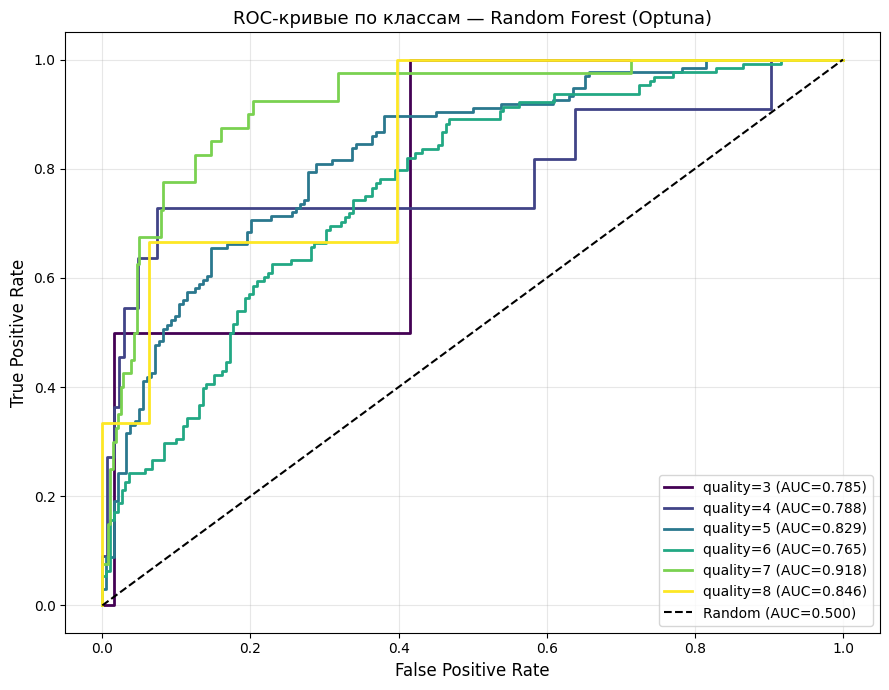

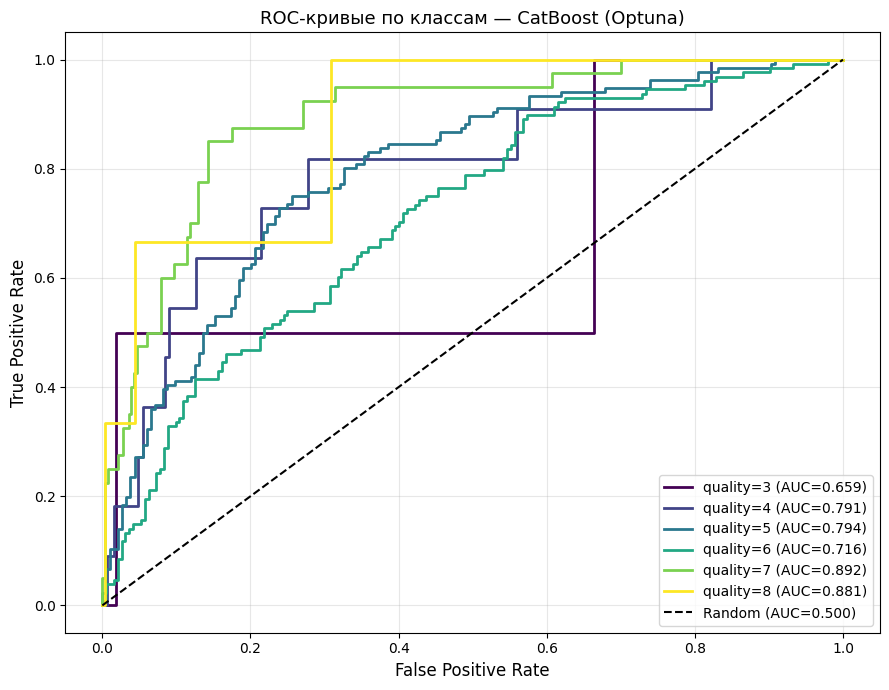

In [24]:
y_test_bin = label_binarize(y_test, classes=range(N_CLASSES))
colors_roc = plt.cm.viridis(np.linspace(0, 1, N_CLASSES))


def plot_roc_curves(y_true_bin, y_proba, model_name):
    fig, ax = plt.subplots(figsize=(9, 7))
    for i in range(N_CLASSES):
        if y_true_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors_roc[i], lw=2,
                label=f'quality={le.classes_[i]} (AUC={roc_auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC=0.500)')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC-кривые по классам — {model_name}', fontsize=13)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_roc_curves(y_test_bin, y_proba_rf_best,  'Random Forest (Optuna)')
plot_roc_curves(y_test_bin, y_proba_cb_best,  'CatBoost (Optuna)')


> **Вывод:** 

Наивысшие показатели площади под кривой наблюдаются для вин с хорошими и отличными оценками качества. Это объясняется тем, что такие объекты обладают более выраженным химическим профилем, который позволяет алгоритмам увереннее отделять их от основной массы. В то же время, средние классы гораздо труднее поддаются безошибочной классификации из-за сильного взаимного пересечения признаков.

Разрыв в форме кривых между классами является прямым следствием сильного дисбаланса исходного датасета. Графики для самых редких оценок выглядят крайне нестабильно и ступенчаты из-за острого дефицита тестовых примеров любое предсказание вызывает резкий скачок метрики. Мажоритарные же классы формируют плавные линии благодаря достаточному объему данных для более гладкой оценки вероятностей.


## 4. Анализ пересечения ошибок

> Пересечение ошибок двух моделей показывает «тяжёлые» объекты — те примеры, с которыми не справляются оба алгоритма одновременно. Они же будут выбраны для локальной интерпретации в разделе VI.


In [25]:
idx_all = np.arange(len(y_test))

correct_rf = set(idx_all[y_pred_rf_best == y_test])
correct_cb = set(idx_all[y_pred_cb_best == y_test])
wrong_rf   = set(idx_all[y_pred_rf_best != y_test])
wrong_cb   = set(idx_all[y_pred_cb_best != y_test])

shared_correct = sorted(correct_rf & correct_cb)
shared_wrong   = sorted(wrong_rf   & wrong_cb)
only_rf_wrong  = sorted(wrong_rf   - wrong_cb)
only_cb_wrong  = sorted(wrong_cb   - wrong_rf)

intersection_data = [
    ('Оба правы',           len(shared_correct)),
    ('Оба ошибаются',       len(shared_wrong)),
    ('Только RF ошибается', len(only_rf_wrong)),
    ('Только CB ошибается', len(only_cb_wrong)),
]
inter_df = pd.DataFrame(intersection_data, columns=['Категория', 'Количество'])
print('Анализ пересечения ошибок:')
display(inter_df)

fig = px.bar(
    inter_df, x='Категория', y='Количество',
    text='Количество',
    color='Категория',
    color_discrete_sequence=['seagreen', 'crimson', 'steelblue', 'coral'],
    title='Пересечение ошибок: RF vs CatBoost',
    width=700, height=420,
)
fig.update_traces(textposition='outside')
fig.update_layout(
    title={'x': 0.5, 'xanchor': 'center'},
    showlegend=False,
)
fig.show()

# Выбираем до 10 объектов каждой категории для локального XAI
local_correct_idx = shared_correct[:10]
local_wrong_idx   = shared_wrong[:10]
local_idx         = local_correct_idx + local_wrong_idx

print(f'\nДля локального XAI выбрано:')
print(f'  Верных (общих для RF и CB):   {len(local_correct_idx)}')
print(f'  Ошибочных (общих для RF и CB): {len(local_wrong_idx)}')
print(f'  Итого:                         {len(local_idx)}')


Анализ пересечения ошибок:


,Категория,Количество
0,Оба правы,169
1,Оба ошибаются,99
2,Только RF ошибается,13
3,Только CB ошибается,39



Для локального XAI выбрано:
  Верных (общих для RF и CB):   10
  Ошибочных (общих для RF и CB): 10
  Итого:                         20


> **Вывод:**

Оба алгоритма одновременно классифицируют неверно 99 объектов, что составляет примерно 31% от всей тестовой выборки (99 из 320 наблюдений). Наличие такой значимой доли общих ошибок говорит о существовании фундаментально «трудных» примеров, для которых текущего признакового пространства просто недостаточно. Это означает, что в датасете присутствуют пограничные случаи (вина соседних классов качества) с настолько схожими химическими характеристиками, что ни градиентный бустинг, ни случайный лес не могут провести между ними четкую границу.


# VI. Интерпретируемость (XAI)

Все методы интерпретации применяются к **оптимизированным моделям** (`rf_best`, `cb_best`). Для методов, требующих выбора одного класса, используется **`TARGET_CLASS_IDX`** (индекс quality=6 — наиболее распространённый класс).

## 1. Глобальная интерпретация

### 1.1 Permutation Importance

> Permutation Importance — это model-agnostic метод: он перемешивает значения признака и измеряет падение метрики. В отличие от встроенной важности деревьев, он учитывает корреляции между признаками.


In [26]:
for model_obj, model_label in [(rf_best, 'Random Forest'), (cb_best, 'CatBoost')]:
    perm_res = permutation_importance(
        model_obj, X_test_scaled, y_test,
        n_repeats=10, random_state=RANDOM_STATE,
        scoring='f1_macro', n_jobs=-1,
    )
    perm_df = pd.DataFrame({
        'feature':    FEATURE_COLS,
        'importance': perm_res.importances_mean,
        'std':        perm_res.importances_std,
    }).sort_values('importance', ascending=True)

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=perm_df['importance'], y=perm_df['feature'],
        orientation='h', marker_color='steelblue',
        error_x=dict(type='data', array=perm_df['std'], visible=True),
    ))
    fig.update_layout(
        title={'text': f'Permutation Importance — {model_label}', 'x': 0.5, 'xanchor': 'center'},
        xaxis_title='Снижение F1 Macro при перемешивании',
        yaxis_title='Признак',
        template='plotly_white', width=800, height=550, showlegend=False,
    )
    fig.show()


> **Вывод:** 

Топ-5 наиболее важных признаков у моделей совпадают лишь частично. Оба алгоритма единогласно выделяют классические химические маркеры (сульфаты и летучую кислотность) как наиболее критичные для правильной классификации. Однако, далее их логика расходится: случайный лес отдает приоритет базовым показателям среды, тогда как градиентный бустинг извлекает больше пользы из сгенерированных составных признаков и параметров диоксида серы.

Из-за того, что химические профили смежных классов качества сильно пересекаются, модели разной архитектуры находят альтернативные пути в признаковом пространстве для принятия решений. Очевидно, задача нетривиальная, т.к. итоговая оценка (целевая переменная) является субъективным взглядом человека на совокупность характеристик вина, которую он интепретирует органолептическим методом (пробует и говорит вкусно, не вкусно).


### 1.2 Partial Dependence Plots (PDP) — Random Forest

> PDP показывает усреднённое влияние одного признака на вероятность предсказания конкретного класса при прочих равных условиях. Здесь анализируется класс `quality=6` (`TARGET_CLASS_IDX={TARGET_CLASS_IDX}`).


Топ-5 признаков для PDP: ['sulphates', 'volatile acidity', 'pH', 'fixed acidity', 'alc_density_prod']


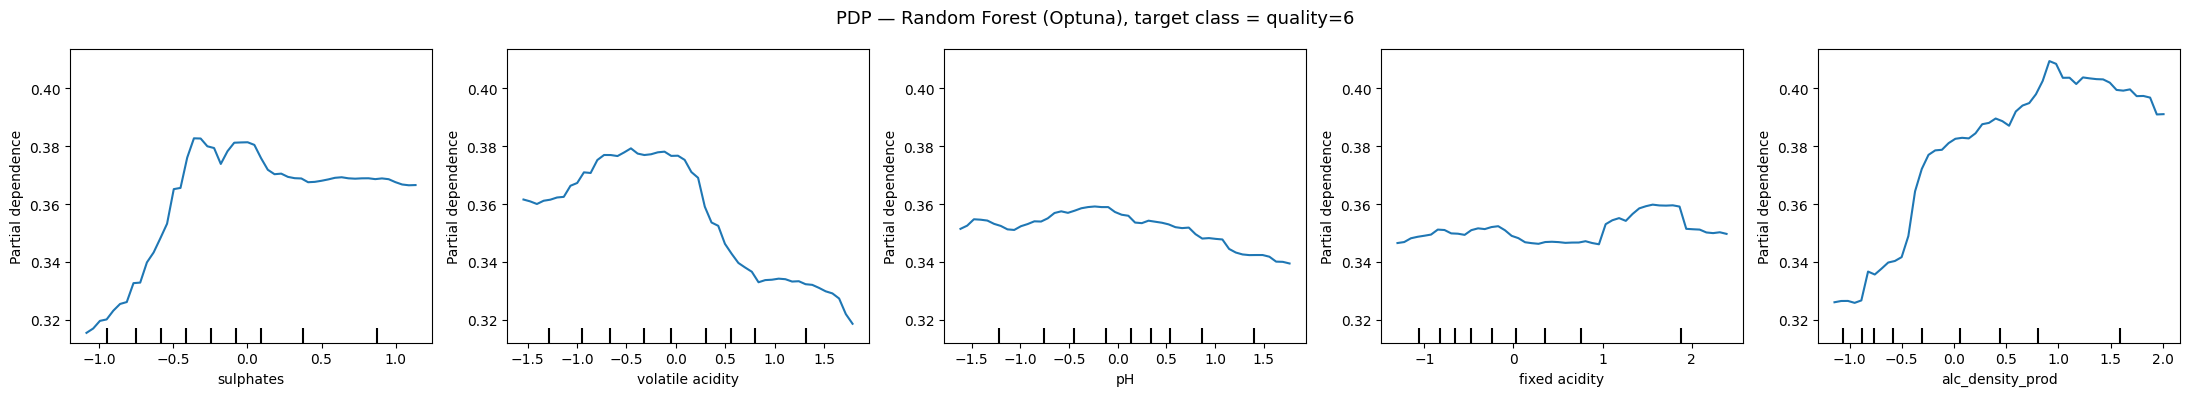

In [27]:
# Топ-5 признаков по Permutation Importance (RF)
perm_rf = permutation_importance(
    rf_best, X_test_scaled, y_test,
    n_repeats=5, random_state=RANDOM_STATE,
    scoring='f1_macro', n_jobs=-1,
)
top5_idx   = np.argsort(perm_rf.importances_mean)[::-1][:5]
top5_names = [FEATURE_COLS[i] for i in top5_idx]
print(f'Топ-5 признаков для PDP: {top5_names}')

fig_pdp, axes_pdp = plt.subplots(1, 5, figsize=(22, 4))
PartialDependenceDisplay.from_estimator(
    rf_best,
    X_test_scaled,
    features=top5_names,
    target=TARGET_CLASS_IDX,
    kind='average',
    ax=axes_pdp,
    grid_resolution=50,
    random_state=RANDOM_STATE,
)
fig_pdp.suptitle(
    f'PDP — Random Forest (Optuna), target class = quality={le.classes_[TARGET_CLASS_IDX]}',
    fontsize=13,
)
plt.tight_layout()
plt.show()


> **Вывод:** 

Увеличение значений sulphates и alc_density_prod от минимальных до средних отметок резко повышает вероятность отнесения вина к классу 6, после чего их влияние выходит на плато. Напротив, рост volatile acidity выше среднего уровня стремительно снижает шансы на предсказание этого класса. Признак pH демонстрирует лишь слабое плавное снижение вероятности при высоких значениях, а fixed acidity в изолированном виде практически не меняет маргинальную вероятность, образуя почти горизонтальную линию.

Если говорить по простому - сульфаты и синтетический признак (алкоголь х плотность) до определенного уровня сильно влияют на оценку, но после определенного порога изменения прекращаются. По поводу летучей кислотности - как только норма превышается, шансы на нормальную оценку резко падают - по сути, главный враг качественного вина. А pH и постоянная кислотность почти не влияют на расхождения оценок, разве что, увеличение pH может немного подпортить картину.

### 1.3 SHAP Summary Plot — Random Forest

> SHAP (SHapley Additive exPlanations) — это метод, основанный на теории кооперативных игр. Он вычисляет вклад каждого признака в отклонение предсказания от базового значения (mean). Для мультикласса SHAP-значения вычисляются отдельно для каждого класса — здесь визуализируем класс `TARGET_CLASS_IDX` (quality=6).


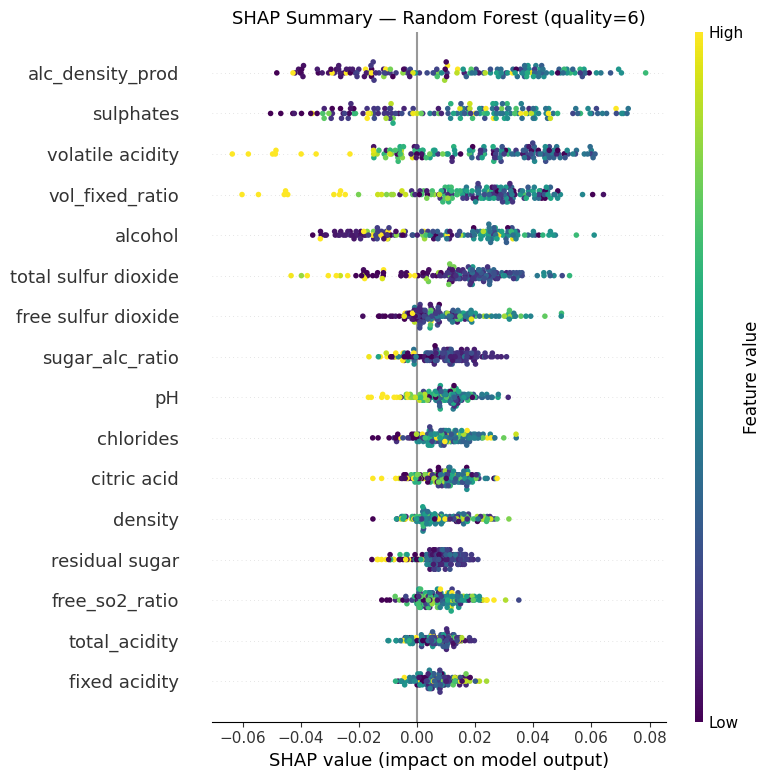

In [28]:
SHAP_SAMPLE_SIZE = 150
rng_shap = np.random.default_rng(RANDOM_STATE)
shap_idx = rng_shap.choice(len(X_test_scaled), size=SHAP_SAMPLE_SIZE, replace=False)
X_shap = X_test_scaled.iloc[shap_idx]

explainer_rf = shap.TreeExplainer(rf_best)
sv_rf = explainer_rf.shap_values(X_shap, check_additivity=False)

# SHAP 0.45+: shap_values возвращает 3D-массив (n_samples, n_features, n_classes),
# старые версии — список массивов (один на класс)
if isinstance(sv_rf, list):
    sv_rf_target = sv_rf[TARGET_CLASS_IDX]
else:
    sv_rf_target = sv_rf[:, :, TARGET_CLASS_IDX]
ev_rf_target = explainer_rf.expected_value[TARGET_CLASS_IDX]

plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv_rf_target,
    X_shap,
    feature_names=FEATURE_COLS,
    cmap=plt.cm.viridis,
    show=False,
)
plt.title(f'SHAP Summary — Random Forest (quality={le.classes_[TARGET_CLASS_IDX]})', fontsize=13)
plt.tight_layout()
plt.show()


> **Вывод:** 

Наибольший вклад в предсказания модели случайного леса (для класса 6) по метрике SHAP вносит синтетический признак alc_density_prod. Это не полностью совпадает с результатами глобального Permutation Importance, где абсолютным лидером выступали сульфаты. Подобное различие естественно - SHAP-значения на данном графике показывают распределение локальных вкладов признака в предсказание конкретно 6-го класса, в то время как Permutation Importance оценивал общее падение усредненной F1-метрики по всем классам сразу.

График демонстрирует сильное разнонаправленное влияние топовых признаков. Например, высокие значения летучей кислотности (желтые точки) формируют длинный хвост отрицательных SHAP-значений, резко снижая вероятность предсказания 6-го класса, тогда как ее низкие значения (темные точки) толкают предсказание в плюс. Зеркальная ситуация наблюдается у признака sulphates: здесь именно низкие значения уводят вероятность в минус, а более высокие — работают на увеличение шансов.


### 1.4 SHAP Summary Plot — CatBoost


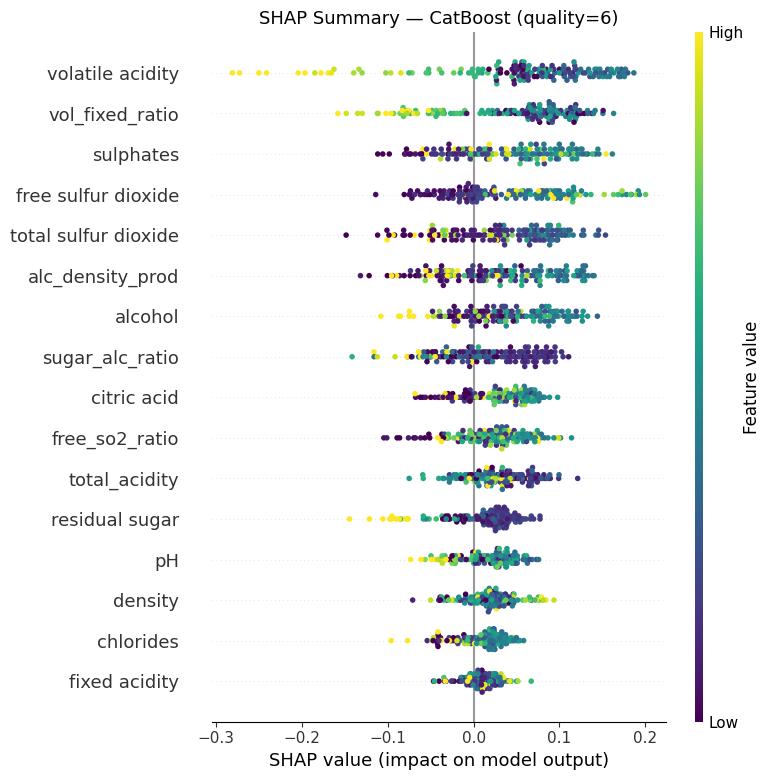

In [29]:
explainer_cb = shap.TreeExplainer(cb_best)
sv_cb = explainer_cb.shap_values(X_shap)

# Обработка обоих форматов: список или 3D-массив
if isinstance(sv_cb, list):
    sv_cb_target = sv_cb[TARGET_CLASS_IDX]
    ev_cb_target = explainer_cb.expected_value[TARGET_CLASS_IDX]
else:
    sv_cb_target = sv_cb[:, :, TARGET_CLASS_IDX]
    ev_cb_target = explainer_cb.expected_value[TARGET_CLASS_IDX]

plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv_cb_target,
    X_shap,
    feature_names=FEATURE_COLS,
    cmap=plt.cm.viridis,
    show=False,
)
plt.title(f'SHAP Summary — CatBoost (quality={le.classes_[TARGET_CLASS_IDX]})', fontsize=13)
plt.tight_layout()
plt.show()


> **Вывод:** 

Профили SHAP для Random Forest и CatBoost совпадают лишь в базовом наборе ключевых маркеров, но заметно различаются в расстановке приоритетов. Если случайный лес делал основную ставку на сгенерированный признак alc_density_prod и сульфаты, то градиентный бустинг вывел в абсолютные лидеры volatile acidity и её пропорцию vol_fixed_ratio. Кроме того, CatBoost гораздо жестче штрафует объекты за высокие значения летучей кислотности, формируя очень длинный хвост сильных отрицательных SHAP-значений.

Принципиальная разница в интерпретации продиктована самой архитектурой алгоритмов. Случайный лес строит независимые деревья и склонен более равномерно распределять важность между коррелирующими характеристиками. Градиентный бустинг обучается последовательно, агрессивно фокусируясь на исправлении ошибок, поэтому он способен выжать максимум из нескольких наиболее дискриминативных признаков, отводя остальным вспомогательную роль.


## 2. Локальная интерпретация

Для локальной интерпретации используем **20 объектов**: 10 верно классифицированных и 10 ошибочно классифицированных — **общих для обеих моделей** (выбранных в разделе V.4).

### 2.1 SHAP Heatmap (20 объектов)

> SHAP Heatmap визуализирует матрицу SHAP-значений для всех 20 выбранных объектов. Строки — объекты, столбцы — признаки. Позволяет увидеть, за счёт каких признаков модель правильно или неправильно классифицирует каждый объект.


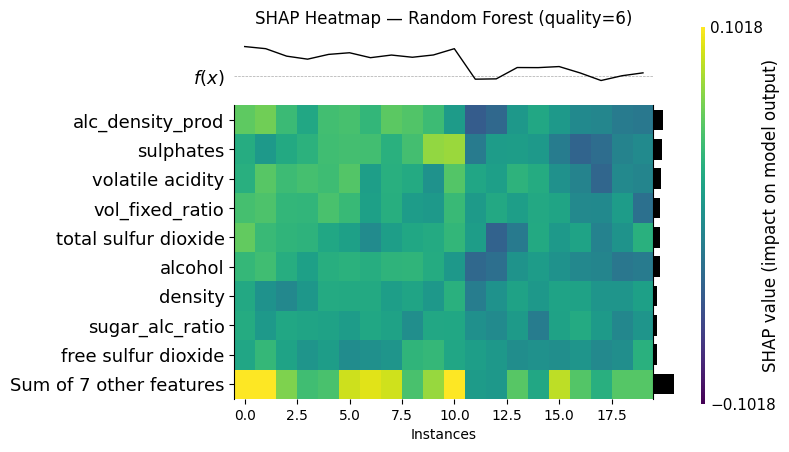

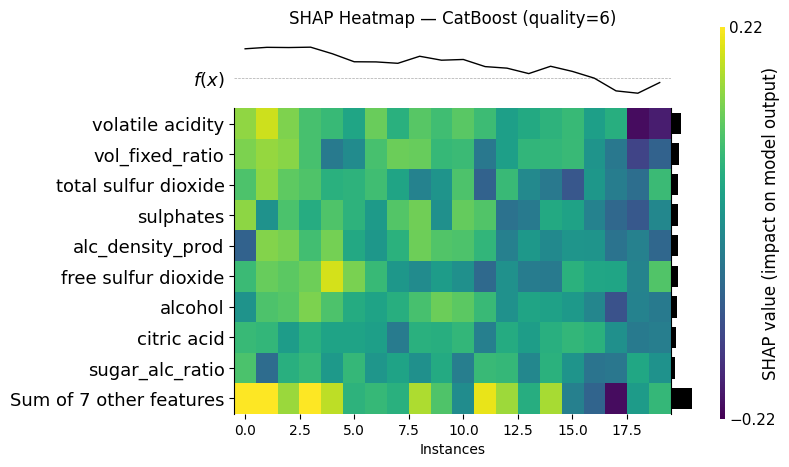

In [30]:
X_local = X_test_scaled.iloc[local_idx].reset_index(drop=True)
labels_local = [
    f'✅ q={le.classes_[y_test[i]]}' if i in local_correct_idx
    else f'❌ q={le.classes_[y_test[i]]}'
    for i in local_idx
]

# RF SHAP Heatmap
sv_rf_local = sv_rf_target[local_idx]
exp_rf_local = shap.Explanation(
    values=sv_rf_local,
    base_values=np.full(len(local_idx), ev_rf_target),
    data=X_local.values,
    feature_names=FEATURE_COLS,
)
plt.figure(figsize=(14, 7))
shap.plots.heatmap(exp_rf_local, cmap=plt.cm.viridis, show=False)
plt.title(f'SHAP Heatmap — Random Forest (quality={le.classes_[TARGET_CLASS_IDX]})', fontsize=12)
plt.tight_layout()
plt.show()

# CatBoost SHAP Heatmap
sv_cb_local = sv_cb_target[local_idx]
exp_cb_local = shap.Explanation(
    values=sv_cb_local,
    base_values=np.full(len(local_idx), ev_cb_target),
    data=X_local.values,
    feature_names=FEATURE_COLS,
)
plt.figure(figsize=(14, 7))
shap.plots.heatmap(exp_cb_local, cmap=plt.cm.viridis, show=False)
plt.title(f'SHAP Heatmap — CatBoost (quality={le.classes_[TARGET_CLASS_IDX]})', fontsize=12)
plt.tight_layout()
plt.show()


> **Вывод:** 

На обеих тепловых картах четко прослеживается разница между левой и правой половинами: на первых 10 (верных) объектах верхняя линия предсказания $f(x)$ стабильно держится выше базового уровня, поддерживаемая светло-зелеными и желтыми (положительными) значениями ключевых признаков. В то же время на последних 10 объектах (где обе модели ошибаются) предсказание проваливается, и матрица окрашивается в темно-синие и фиолетовые тона.

Согласованно на протяжении всех объектов у Random Forest работают признаки alc_density_prod и sulphates - они либо совместно двигают вероятность вверх на правильных примерах, либо синхронно уходят в глубокий минус на ошибочных. У CatBoost ту же согласованную динамику задают volatile acidity и vol_fixed_ratio. 

Паттерн ошибочных объектов характеризуется тем, что модели сталкиваются с комбинацией характеристик, которая противоречит выученным правилам (например, объект имеет уровень летучей кислотности характеризурющийся как плохой, но является вином с оценкой 6), из-за чего топовые признаки вносят сильный отрицательный штраф, подавляя любой слабый положительный сигнал от остальных фичей.

### 2.2 SHAP Waterfall (точечный анализ)

> Waterfall plot — детальное объяснение отдельного объекта: показывает, насколько каждый признак «сдвигает» предсказание от базового значения (E[f(X)]) к финальному предсказанию f(x). Анализируем один верный и один ошибочный объект.



Объект #2 (верно классифицированный): истинный класс = 5, RF предсказал = 5


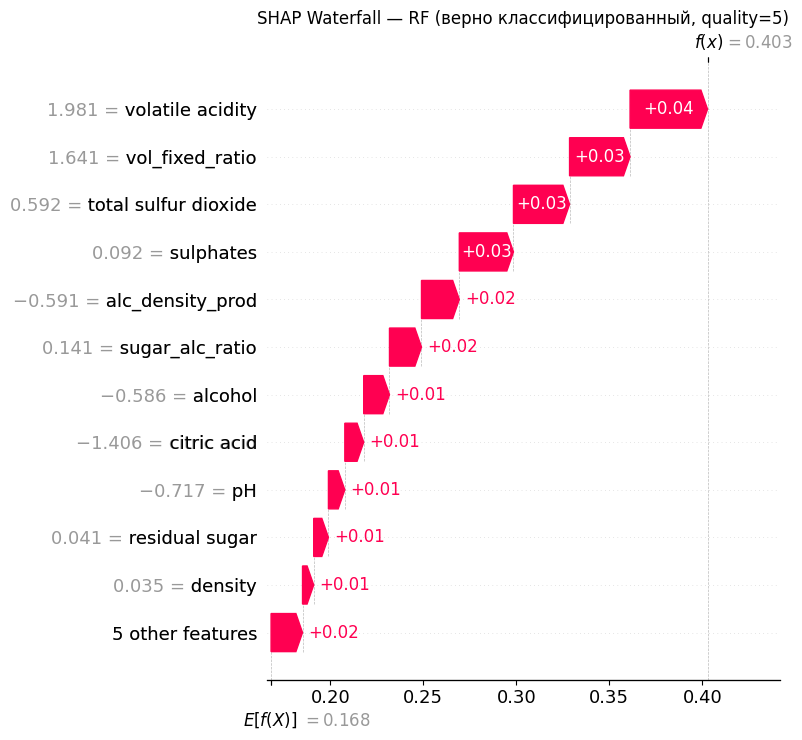

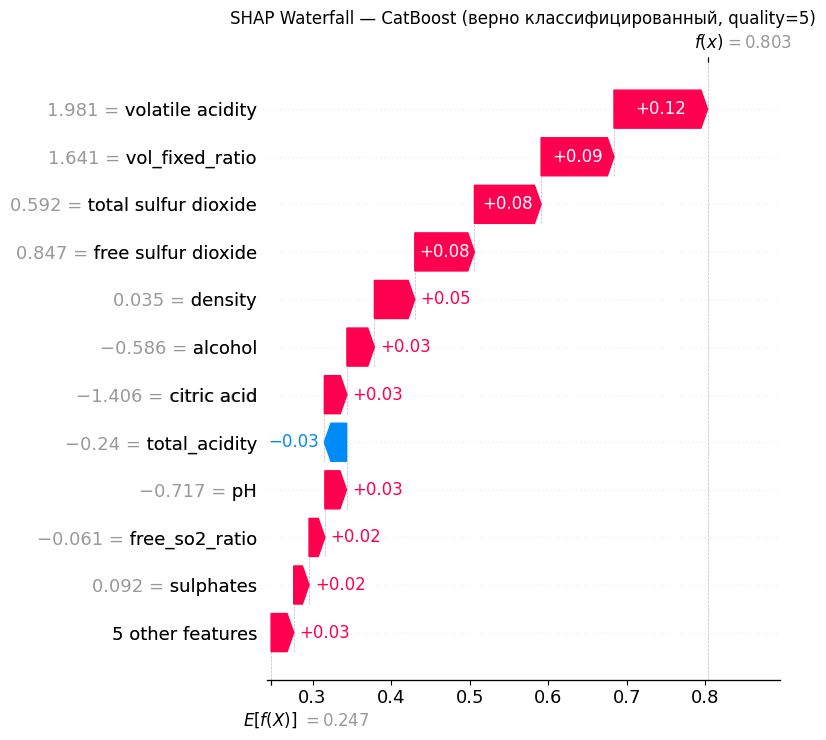


Объект #0 (ошибочно классифицированный): истинный класс = 6, RF предсказал = 7


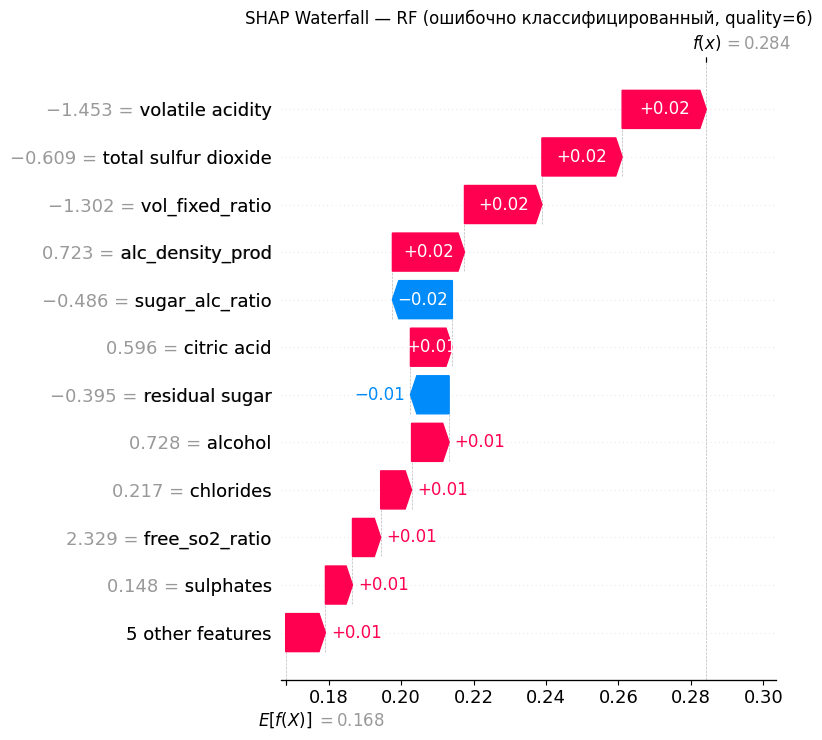

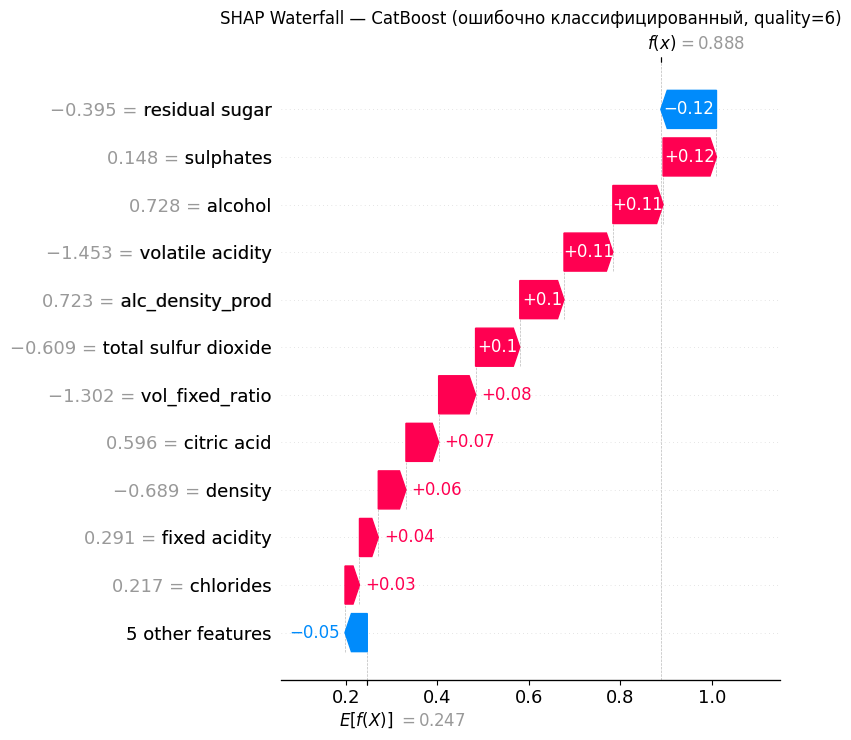

In [31]:
for sample_pos, label in [(0, 'верно классифицированный'), (len(local_correct_idx), 'ошибочно классифицированный')]:
    orig_idx = local_idx[sample_pos]
    true_q   = le.classes_[y_test[orig_idx]]
    pred_q_rf = le.classes_[y_pred_rf_best[orig_idx]]

    print(f'\nОбъект #{orig_idx} ({label}): истинный класс = {true_q}, RF предсказал = {pred_q_rf}')

    # RF Waterfall
    exp_rf_single = shap.Explanation(
        values=sv_rf_target[orig_idx],
        base_values=ev_rf_target,
        data=X_test_scaled.iloc[orig_idx].values,
        feature_names=FEATURE_COLS,
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp_rf_single, max_display=12, show=False)
    plt.title(f'SHAP Waterfall — RF ({label}, quality={true_q})', fontsize=12)
    plt.tight_layout()
    plt.show()

    # CatBoost Waterfall
    exp_cb_single = shap.Explanation(
        values=sv_cb_target[orig_idx],
        base_values=ev_cb_target,
        data=X_test_scaled.iloc[orig_idx].values,
        feature_names=FEATURE_COLS,
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp_cb_single, max_display=12, show=False)
    plt.title(f'SHAP Waterfall — CatBoost ({label}, quality={true_q})', fontsize=12)
    plt.tight_layout()
    plt.show()


> **Вывод:** 

Для верно классифицированного объекта (quality=5) обе модели действуют вполне согласованно: и Random Forest, и CatBoost отталкиваются от одних и тех же ключевых признаков — высокой летучей кислотности (volatile acidity = 1.981), пропорции vol_fixed_ratio и total sulfur dioxide, которые вносят наибольший положительный вклад в предсказание. При этом CatBoost гораздо агрессивнее наращивает вероятность (до $f(x)=0.803$ против $0.403$ у леса) за счет более сильных весов тех же самых факторов.

Однако на ошибочно классифицированном объекте (фактический класс не 6) их объяснения расходятся. Random Forest ошибается относительно "осторожно" ($f(x)=0.284$), и его ошибку формируют разрозненные слабые сигналы: низкая летучая кислотность и диоксид серы. CatBoost же ошибается с огромной уверенностью ($f(x)=0.888$), и эту ошибку провоцируют совершенно другие драйверы — в первую очередь, сульфаты (sulphates = 0.148) и алкоголь (alcohol = 0.728), которые дают мощный ложный сигнал, перевешивающий даже отрицательный вклад остаточного сахара (residual sugar).

Это говорит о том, что в сложных пограничных случаях модели могут прийти к неверному ответу (или одному и тому же ответу), опираясь на совершенно разные, иногда противоречащие друг другу комбинации признаков


### 2.3 LIME (локальная суррогатная интерпретация)

> LIME строит локальную линейную модель в окрестности конкретного объекта. В отличие от SHAP, LIME — более универсален и работает как чёрный ящик. Сравниваем объяснения LIME и SHAP для одних и тех же объектов.



LIME — Random Forest (верно классифицированный, истинный класс quality=5)


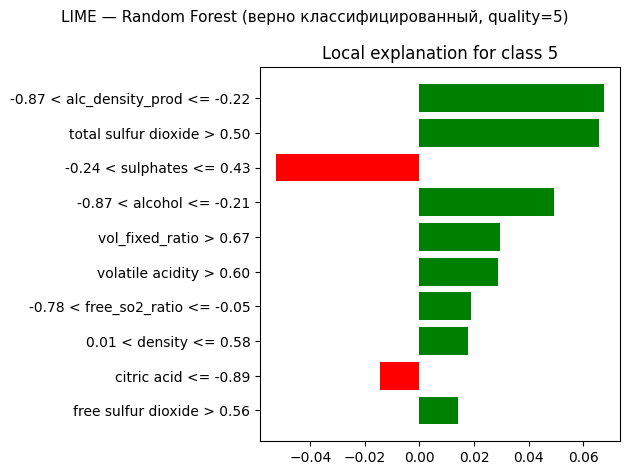


LIME — CatBoost (верно классифицированный, истинный класс quality=5)


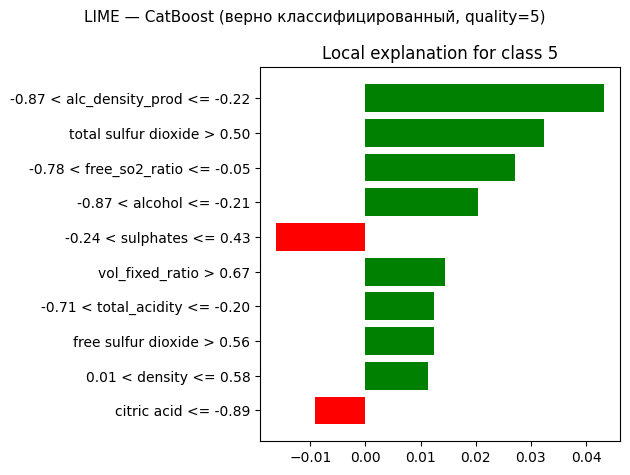


LIME — Random Forest (ошибочно классифицированный, истинный класс quality=6)


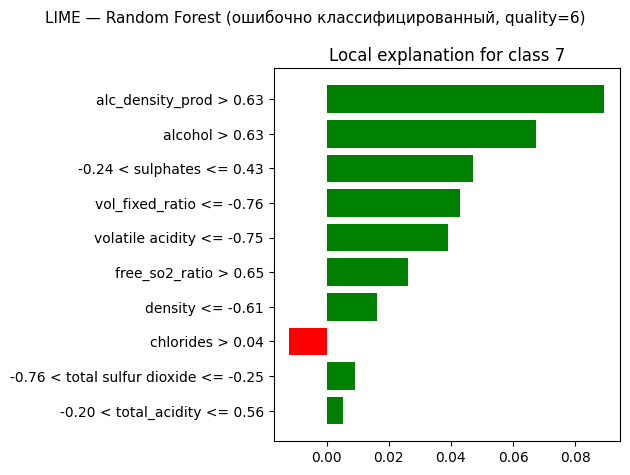


LIME — CatBoost (ошибочно классифицированный, истинный класс quality=6)


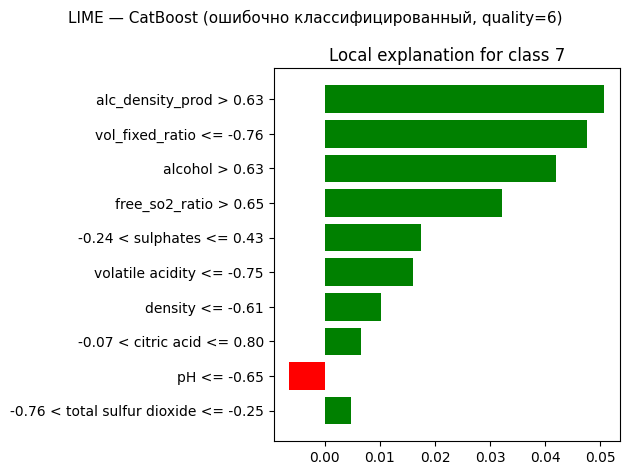

✅ LIME объяснения построены


In [32]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=FEATURE_COLS,
    class_names=CLASS_NAMES,
    mode='classification',
    random_state=RANDOM_STATE,
)


def explain_with_lime(model, model_name, sample_idx, label):
    '''Строит LIME-объяснение для одного объекта и визуализирует его.'''
    true_q = le.classes_[y_test[sample_idx]]
    exp = lime_explainer.explain_instance(
        data_row=X_test_scaled.iloc[sample_idx].values,
        predict_fn=model.predict_proba,
        num_features=10,
        top_labels=1,
    )
    print(f'\nLIME — {model_name} ({label}, истинный класс quality={true_q})')
    predicted_label = exp.available_labels()[0]
    fig = exp.as_pyplot_figure(label=predicted_label)
    fig.suptitle(f'LIME — {model_name} ({label}, quality={true_q})', fontsize=11)
    plt.tight_layout()
    plt.show()


correct_sample_idx = local_idx[0]
wrong_sample_idx   = local_idx[len(local_correct_idx)]

for sample_idx, label in [
    (correct_sample_idx, 'верно классифицированный'),
    (wrong_sample_idx,   'ошибочно классифицированный'),
]:
    explain_with_lime(rf_best,  'Random Forest', sample_idx, label)
    explain_with_lime(cb_best,  'CatBoost',      sample_idx, label)

print('✅ LIME объяснения построены')


> **Вывод:** 

Объяснения LIME и SHAP для одних и тех же объектов совпадают лишь в общих чертах, но заметно расходятся в деталях и оценке силы влияния. Например, на верно классифицированном объекте (quality=5) обе метрики согласны в том, что total sulfur dioxide, vol_fixed_ratio и volatile acidity оказывают положительное влияние на предсказание. Однако LIME выделяет признак alc_density_prod как самый сильный положительный фактор, в то время как SHAP для Random Forest оценивал его вклад как отрицательный (−0.591). На ошибочном объекте (классифицированном как 7) LIME также находит сильную поддержку в признаках alc_density_prod и alcohol, но практически игнорирует sulphates, который по версии SHAP был одним из главных виновников ошибки у CatBoost.

Подобные расхождения связаны с самой природой алгоритма LIME, который строит локальную линейную суррогатную модель вокруг конкретной точки путем генерации случайных возмущений (пертурбаций). В условиях сложного, сильно мультиколлинеарного признакового пространства эти возмущения могут "зацеплять" артефакты, не свойственные реальным данным, из-за чего локальная линейная аппроксимация становится нестабильной. Поэтому в задачах с выраженными нелинейными зависимостями (как было показано на графиках PDP) объяснениям SHAP, основанным на строгой теории кооперативных игр и точном учете структуры деревьев (TreeExplainer), можно доверять больше, чем линейным аппроксимациям LIME.


# VII. Выводы

## 1. Обзор результатов

Универсального лидера по всем метрикам выявить не удалось. 

Базовый Random Forest показал лучший результат по F1 Macro (0.4023), но оказался сильно переобученным. CatBoost (baseline) лучше справился с усредненной полнотой, достигнув максимальной Balanced Accuracy (0.4233). 

После оптимизации гиперпараметров через Optuna, Random Forest продемонстрировал наивысшую ранжирующую способность с ROC AUC (OvR) 0.8218, однако это произошло ценой снижения точности жесткой классификации. 

Мое предпочтение остается за CatBoost, так как у этой модели ниже переобучение. В будущем, хочу попробовать погонять optuna еще, когда разберусь, как через CUDA тренировать алгоритмы на винде.

## 2. Сравнение природы алгоритмов

Архитектурные различия алгоритмов хорошо проявились в расстановке приоритетов. 

Random Forest (бэггинг) склонен более равномерно распределять важность между скоррелированными признаками и действует консервативно, концентрируя предсказания вокруг мажоритарных классов. 

CatBoost (бустинг) обучается последовательно, фокусируясь на исправлении ошибок, поэтому он агрессивнее ищет редкие классы и извлекает максимум сигнала из нескольких самых сильных признаков. 

Случайный лес оказался предпочтительнее для стабильных вероятностных оценок (ROC AUC), а бустинг — когда критически важно не упустить миноритарные примеры (Balanced Accuracy).

## 3. Интерпретируемость и XAI

Ключевыми маркерами качества вина выступают сульфаты (sulphates), летучая кислотность (volatile acidity), а также искусственно сгенерированные признаки (alc_density_prod, vol_fixed_ratio). 

Глобальные методы (Permutation Importance) и локальные (SHAP) в целом согласованы в определении топа признаков, но расходятся в оценке их веса для конкретных моделей. Зависимости носят сложный нелинейный характер, что подтверждают графики PDP. 

LIME показал себя менее надежным суррогатом: из-за построения линейных аппроксимаций в сильно мультиколлинеарном пространстве его локальные объяснения иногда противоречат более строгой логике SHAP.

## 4. Проблема дисбаланса классов

Экстремальный дефицит объектов для классов 3 и 8 (всего 2 и 3 примера в тестовой выборке соответственно) привел к тому, что алгоритмы практически не способны их распознавать — точность и полнота на них падают до нуля. На графиках ROC-кривых это отразилось в виде угловатых, нестабильных ступеней. 

Обычная метрика Accuracy в таких условиях абсолютно неинформативна, поэтому реальное положение дел адекватно отразили только F1 Macro и Balanced Accuracy, которые не позволили мажоритарным классам замаскировать провалы на редких оценках качества.

## 5. Выводы по анализу ошибок

Около 31% тестовой выборки (99 объектов) классифицируется неверно обеими моделями одновременно. Большинство промахов алгоритмов приходится на соседние оценки качества из-за сильного пересечения их химических профилей. 

Локальный анализ через SHAP (Heatmap и Waterfall) выявил четкую закономерность: "тяжелые" объекты обладают противоречивыми характеристиками (например, маркеры указывают на низкое качество, хотя фактический класс средний). На таких примерах топовые признаки вносят сильный отрицательный штраф, подавляя любые слабые положительные сигналы от остальных переменных, что одинаково сбивает с толку модели любой архитектуры.

## 6. Кто виноват и что делать?

Для радикального решения проблемы дисбаланса стоит попытаться внедрить методы аугментации данных, такие как SMOTE или ADASYN. Поскольку под капотом эти методы опираются на поиск ближайших соседей (k-NN), они позволят синтезировать новые, реалистичные примеры для редких оценок (3 и 8), избегая простого дублирования строк. 

Дополнительным шагом может стать интеллектуальное сжатие мажоритарных классов 5 и 6 с помощью алгоритмов кластеризации (например, K-Means или DBSCAN), что поможет удалить пересекающиеся «шумные» примеры и сделать границы классов более четкими. 

Наконец, итоговое качество можно повысить за счет применения методов понижения размерности (например, PCA) для устранения мультиколлинеарности сгенерированных признаков, а также проведения более глубокой и продолжительной оптимизации гиперпараметров.
